#### Note:
- This notebook contains the accompanying code for the "A machine learning model for multi-classification of quenched and partitioned steel microstructure type by the k-nearest neighbour algorithm". The dataset was created by Computational Materials Enginnering Lab, Department of Metallurgical and Materials Enggineering, National Institute of Technology Raipur India.

- The dataset contains a distaste of size 348×9 covering the feature vector C (wt.%), Si (wt.%), Mn (wt.%), TMAE (wt.%), Ac1 (℃), Ac3 (℃), Ms (℃), QT (℃), PT (℃). QT and PT represent the Quenching Temperature and Partitioning Temperature, respectively. 

- This particular notebook guides the reader through the creation of a computer-vision baseline model that is able to automatically uses the k_NN model for the classification of the microstructure-type of QP steels. It also includes the code that uses decision tree, random forest, SVM classifier. The purpose is to exemplify and guide the training of more sophisticated machine learning classification models and to show how to measure their accuracy.

Contact: Subhas Ganguly, PhD (sganguly.mme@nitrr.ac.in)

# 1. Import

In [22]:
# import
import pandas as pd
import numpy as np

# Scaling
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# for ploting
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Data Preprocessing

In [23]:
from imblearn.over_sampling import SMOTE
from collections import Counter # It allows you to count the items in an iterable list.
dataset = pd.read_csv('QPdata_coded_all.csv')
dataset.describe()

,C,Si,Mn,TMAE,AC1,AC3,MS,Qtemp,Ptemp,MicroStrucType
count,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000
mean,0.293744,1.346621,2.116658,0.018245,742.417853,829.258225,359.014080,228.508621,367.097701,2.660920
std,0.177569,0.538792,1.178823,0.046366,13.013620,35.755291,61.234635,76.296195,80.296868,1.842493
min,0.030000,0.000000,0.240000,0.000000,693.868000,703.280000,120.000000,10.000000,150.000000,0.000000
25%,0.200000,1.285000,1.497500,0.000000,736.597000,813.670548,324.250000,190.000000,320.000000,0.000000
50%,0.220000,1.500000,1.800000,0.000000,745.400000,835.583582,381.000000,230.000000,400.000000,4.000000
75%,0.300000,1.628000,2.450000,0.001000,752.482400,858.709808,401.000000,280.000000,400.000000,4.000000
max,1.200000,2.600000,6.000000,0.300000,772.504000,916.435459,453.600000,550.000000,650.000000,5.000000


### SMOTE

In [21]:
from imblearn.over_sampling import SMOTE
from collections import Counter # It allows you to count the items in an iterable list.
X=dataset.iloc[:,:-1]
y=dataset.iloc[:,-1]
oversample=SMOTE(random_state=10)
X_sm,y_sm=oversample.fit_resample(X,y)
counter=Counter(y_sm)
counter

Counter({0: 146, 1: 146, 2: 146, 3: 146, 4: 146, 5: 146})

### Splitting of dataset

In [4]:
# Splitting the dataset into the Training set and Test set

X_train, X_test, y_train, y_test = train_test_split(X_sm, y_sm, test_size=0.3, random_state=0)

### feature scaling

In [5]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# 3. Classification models

## DecisionTreeClassifier

In [6]:
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(max_depth=8, random_state=42)
classifier.fit(X_train, y_train)

# Predicting the Test set results
y_pred = classifier.predict(X_test)

In [7]:
# #Ploting Confusion Matrix
# from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

# cm = confusion_matrix(y_test, y_pred)
# print(cm)
# type(accuracy_score(y_test, y_pred))
# print(accuracy_score(y_test, y_pred))

In [8]:
from sklearn.metrics import f1_score, make_scorer
y_pred_train_gini = classifier.predict(X_train)
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train_gini)))
# print the scores on training and test set

print('Training set score: {:.4f}'.format(classifier.score(X_train, y_train)))
print(f"Training set f1-score; f1_score ={f1_score(y_train, y_pred_train_gini, average='macro')*100:0.1f}")
print('Test set score: {:.4f}'.format(classifier.score(X_test, y_test)))
print(f"Test set f1-score; f1_score ={f1_score(y_test, y_pred, average='macro')*100:0.1f}")

Training-set accuracy score: 0.8515
Training set score: 0.8515
Training set f1-score; f1_score =85.0
Test set score: 0.6958
Test set f1-score; f1_score =69.0


## KNearestNeighbours

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, make_scorer

classifier_knn = KNeighborsClassifier()
classifier_knn.fit  (X_train,y_train)

# predicting the test set results
y_pred_knn=classifier_knn.predict(X_test)

In [10]:
from sklearn.metrics import accuracy_score
y_pred_train_knn = classifier_knn.predict(X_train)
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train_knn)))

# print the scores on training and test set
print('Training set score: {:.4f}'.format(classifier_knn.score(X_train, y_train)))
print(f"Training set f1-score; f1_score ={f1_score(y_train, y_pred_train_knn, average='macro')*100:0.1f}")
print('Test set score: {:.4f}'.format(classifier_knn.score(X_test, y_test)))
print(f"Test set f1-score; f1_score ={f1_score(y_test, y_pred_knn, average='macro')*100:0.1f}")

Training-set accuracy score: 0.8108
Training set score: 0.8108
Training set f1-score; f1_score =80.5
Test set score: 0.7148
Test set f1-score; f1_score =70.1


In [12]:
expdata=pd.read_csv('expdata.csv')
X_newdata = sc.transform(expdata)
y_pred_newdata = classifier_knn.predict(X_newdata)
y_pred_newdata[:]

array([4, 4, 4], dtype=int64)

In [13]:
classifier_knn.get_params(deep=True)

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

In [15]:
# from scipy.stats import randint
# from sklearn.experimental import enable_halving_search_cv  # noqa
# from sklearn.model_selection import HalvingRandomSearchCV
# #max_neighbors
# param_dist = {
#     "n_neighbors": [5,7,9,11,13,15],
#     "weights": ['uniform','distance'],
#     "algorithm": ['ball_tree', 'kd_tree', 'brute'],
#     "leaf_size": [20,30,40],
# }
# rsh = HalvingRandomSearchCV(
#     estimator=classifier_knn, param_distributions=param_dist, factor=2, random_state=42
# )
# rsh.fit(X_train, y_train)
# rsh.best_params_

## Hyperparameter tuning

In [ ]:
    from sklearn.model_selection import GridSearchCV
    #max_neighbors
    param_dist = {
        "n_neighbors": [5,7,9,11,13,15],
        "weights": ['uniform','distance'],
        "algorithm": ['ball_tree', 'kd_tree', 'brute'],
        "leaf_size": [15,20,25,30],
        #"p":[1,2],
    }
    rsh = GridSearchCV(
        estimator=classifier_knn, param_grid=param_dist)
    rsh.fit(X_train, y_train)
    rsh.best_params_

{'algorithm': 'ball_tree',
 'leaf_size': 15,
 'n_neighbors': 5,
 'weights': 'distance'}

In [17]:
classifier_knn = KNeighborsClassifier(n_neighbors = 5,
                                      weights ='distance',
                                      leaf_size = 15,
                                      p = 2,  # default value
                                      algorithm = 'ball_tree')
classifier_knn.fit(X_train,y_train)

# predicting the test set results
y_pred_knn=classifier_knn.predict(X_test)

y_pred_train_knn = classifier_knn.predict(X_train)
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train_knn)))
# print the scores on training and test set

print('Training set score: {:.4f}'.format(classifier_knn.score(X_train, y_train)))
print(f"Training set f1-score; f1_score ={f1_score(y_train, y_pred_train_knn, average='macro')*100:0.1f}")
print('Test set score: {:.4f}'.format(classifier_knn.score(X_test, y_test)))
print(f"Test set f1-score; f1_score ={f1_score(y_test, y_pred_knn, average='macro')*100:0.1f}")

Training-set accuracy score: 0.9706
Training set score: 0.9706
Training set f1-score; f1_score =97.1
Test set score: 0.7833
Test set f1-score; f1_score =77.5


In [18]:
expdata=pd.read_csv('expdata.csv')
X_newdata = sc.transform(expdata)
y_pred_newdata = classifier_knn.predict(X_newdata)
y_pred_newdata[:]

array([4, 4, 4], dtype=int64)

## Model evaluation

In [32]:
from sklearn.metrics import classification_report

CR=classification_report(y_test,y_pred_knn)

print('Classification report \n')
print(CR)

Classification report 

              precision    recall  f1-score   support

           0       0.80      0.77      0.79        48
           1       0.83      0.89      0.86        45
           2       0.79      0.75      0.77        36
           3       0.87      0.91      0.89        45
           4       0.57      0.47      0.51        43
           5       0.77      0.89      0.83        46

    accuracy                           0.78       263
   macro avg       0.77      0.78      0.78       263
weighted avg       0.78      0.78      0.78       263



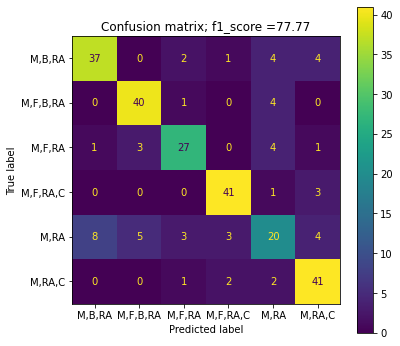

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score, make_scorer

cm = confusion_matrix(y_test, y_pred_knn)

disp=ConfusionMatrixDisplay(confusion_matrix=cm,
                            display_labels=classifier_knn.classes_)
fig, ax = plt.subplots(figsize=(6,6))

disp.plot(ax=ax)
#plt.show()
plt.xticks(np.arange(6), ["M,B,RA", "M,F,B,RA", "M,F,RA", "M,F,RA,C","M,RA","M,RA,C"])
plt.yticks(np.arange(6), ["M,B,RA", "M,F,B,RA", "M,F,RA", "M,F,RA,C","M,RA","M,RA,C"])
plt.title(f"Confusion matrix; f1_score ={f1_score(y_test, y_pred_knn, average='weighted')*100:0.2f}") #accuracy_score
plt.savefig('ConfMat_KNN_test.png',dpi=1000)

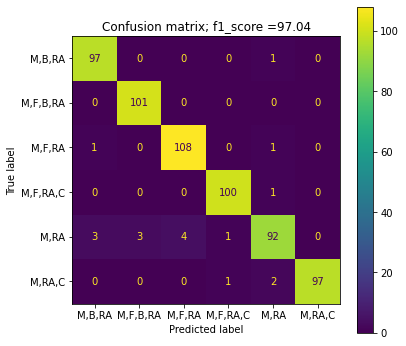

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score, make_scorer

cm = confusion_matrix(y_train, y_pred_train_knn)

disp=ConfusionMatrixDisplay(confusion_matrix=cm,
                            display_labels=classifier_knn.classes_)
fig, ax = plt.subplots(figsize=(6,6))

disp.plot(ax=ax)
#plt.show()
plt.xticks(np.arange(6), ["M,B,RA", "M,F,B,RA", "M,F,RA", "M,F,RA,C","M,RA","M,RA,C"])
plt.yticks(np.arange(6), ["M,B,RA", "M,F,B,RA", "M,F,RA", "M,F,RA,C","M,RA","M,RA,C"])
plt.title(f"Confusion matrix; f1_score ={f1_score(y_train, y_pred_train_knn, average='weighted')*100:0.2f}") #accuracy_score
plt.savefig('ConfMat_KNN_train.png',dpi=1000)

In [1]:
# k vs f1_score plot
no_neighbors = np.arange(5,16)
train_f1score = np.empty(len(no_neighbors))
test_f1score = np.empty(len(no_neighbors))

for i, k in enumerate(no_neighbors):
    knn = KNeighborsClassifier(n_neighbors = k,weights ='distance',leaf_size = 15,algorithm = 'kd_tree')
    knn.fit(X_train,y_train)
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)
    train_f1score[i] = (f1_score(y_train, y_train_pred, average='macro'))*100
    test_f1score[i] = (f1_score(y_test, y_test_pred, average = 'macro'))*100
print(train_f1score)
print(test_f1score)
# plt.yticks([60,70,90,100])
# plt.xticks([5,7,9,11,13,15])

# plt.plot(no_neighbors,test_f1score,label = 'Testing accuracy')
# plt.plot(no_neighbors,train_f1score,label = 'Training accuracy')
# plt.xlabel('Number of Neighbors')
# plt.ylabel('f1_score')
# plt.savefig('plot_kvsf1score.png',dpi=500)

NameError: name 'np' is not defined

## Model Insight

In [140]:
newdata=pd.read_csv('NewData1.csv')
X_newdata = sc.transform(newdata)
y_pred_newdata = classifier_knn.predict(X_newdata)
y_pred_newdata[:]

array([2, 2, 2, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 4, 4, 4, 4, 4, 4, 4, 0,
       4, 4, 4, 4, 4, 4, 4, 4, 5, 2, 2, 4, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0,
       4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 0], dtype=int64)

In [141]:
df2 = pd.DataFrame({"MST":y_pred_newdata})
df3 = df2.replace({'MST':{0:'M,B,RA',1:'M,F,B,RA',2:'M,F,RA',3:'M,F,RA,C',4:'M,RA',5:'M,RA,C'}})
df3=df3.to_numpy()
#df3.to_csv('submission8.csv', index =False)
print(X_newdata[0:11,0])
print(df3[0:11,0])

[-1.53968941 -0.78054624 -0.02140307  0.7377401   1.49688327  2.25602644
  3.01516961  3.77431277  4.53345594  5.29259911  6.05174228]
['M,F,RA' 'M,F,RA' 'M,F,RA' 'M,RA' 'M,RA' 'M,RA' 'M,RA' 'M,B,RA' 'M,B,RA'
 'M,B,RA' 'M,B,RA']


In [2]:
# newdata=pd.read_csv('NewData1.csv')
# X_newdata=newdata.to_numpy()
# plt.figure(figsize=(20,20))
# X_ind_row=0
# # Raw samples plot
# for i in range(1,10):
#   plt.subplot(3,3,i)
#   XX=X_newdata[X_ind_row:11*i,i-1]
#   yy=df3[X_ind_row:i*11,0]
#   #yy=y_pred_newdata[X_ind_row:i*11]
#   plt.plot(XX,yy)
#   X_ind_row=11*i
# #ax=plt.axes()
# #plt.title("Predicted MicrostructureType")
#plt.savefig('MicrostructureType_RFwithoutPCA.png',dpi=200)

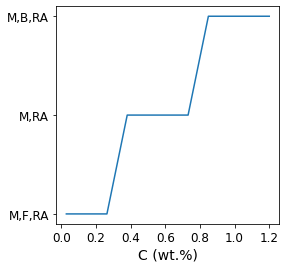

In [143]:
plt.figure(figsize=(4,4))
X_C=X_newdata[0:11,0]
y_C=df3[0:11,0]
plt.plot(X_C,y_C)
plt.xlabel('C (wt.%)',fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
#plt.ylabel('Mcrostructure type')
#plt.yticks(rotation=90)
plt.savefig('plot for C',dpi=300)

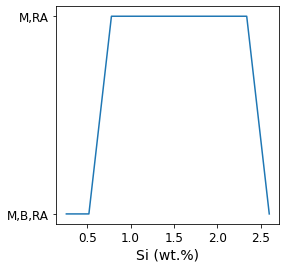

In [144]:
plt.figure(figsize=(4,4))
X_Si=X_newdata[12:22,1]
y_Si=df3[12:22,0]
plt.plot(X_Si,y_Si)
plt.xlabel('Si (wt.%)',fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
#plt.ylabel('Mcrostructure type')
plt.savefig('plot for Si',dpi=300)

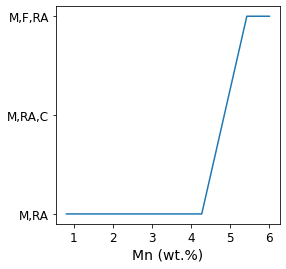

In [145]:
plt.figure(figsize=(4,4))
X_Mn=X_newdata[23:33,2] 
y_Mn=df3[23:33,0]
plt.plot(X_Mn,y_Mn)
plt.xlabel('Mn (wt.%)',fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
#plt.ylabel('Mcrostructure type')
plt.savefig('plot for Mn',dpi=300)


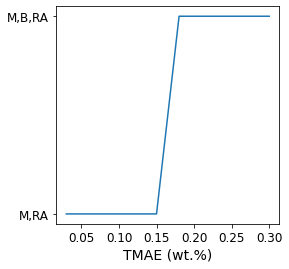

In [146]:
plt.figure(figsize=(4,4))
X_TMAE=X_newdata[34:44,3]
y_TMAE=df3[34:44,0]
plt.plot(X_TMAE,y_TMAE)
plt.xlabel('TMAE (wt.%)',fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
#plt.ylabel('Mcrostructure type')
plt.savefig('plot for TMAE',dpi=300)

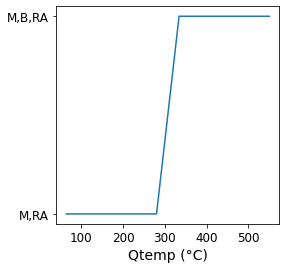

In [147]:
plt.figure(figsize=(4,4))
X_Qtemp=X_newdata[78:88,7] 
y_Qtemp=df3[78:88,0]
plt.plot(X_Qtemp,y_Qtemp) 
plt.xlabel('Qtemp (\u00B0C)',fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
#plt.ylabel('Mcrostructure type')
plt.savefig('plot for Qtemp',dpi=300)
  

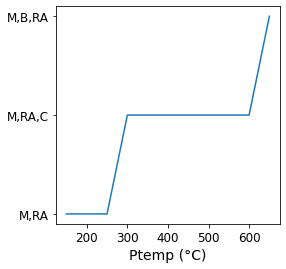

In [148]:
plt.figure(figsize=(4,4))
X_Ptemp=X_newdata[88:99,8]
y_Ptemp=df3[88:99,0]
plt.plot(X_Ptemp,y_Ptemp) 
plt.xlabel('Ptemp (\u00B0C)',fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
#plt.ylabel('Mcrostructure type')
plt.savefig('plot for Ptemp',dpi=300)


In [127]:
newdata=pd.read_csv('C_Si_Mn_TMAE_0.036.csv')
print(newdata[:3])
X_newdata = sc.transform(newdata)
y_pred_newdata = classifier_knn.predict(X_newdata)
y_pred_newdata[:]

      C    Si   Mn   TMAE      AC1         AC3      MS  Qtemp  Ptemp
0  0.03  0.04  1.0  0.036  732.244  882.775459  493.04    220    250
1  0.03  0.68  1.0  0.036  743.892  904.535459  489.84    220    250
2  0.03  1.32  1.0  0.036  755.540  926.295459  486.64    220    250


array([5, 5, 2, 2, 2, 5, 5, 5, 4, 4, 5, 0, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 3, 5, 2, 2, 2, 5, 5, 5, 1, 4, 5, 4, 4, 4, 0, 0, 0, 0, 0,
       5, 0, 0, 0, 4, 0, 3, 3, 2, 2, 2, 5, 0, 0, 1, 1, 5, 4, 4, 4, 0, 0,
       0, 0, 0, 5, 0, 0, 4, 4, 0, 3, 3, 0, 1, 1, 4, 5, 5, 0, 1, 5, 4, 4,
       4, 4, 0, 0, 5, 0, 0, 0, 0, 4, 4, 4, 3, 3, 0, 1, 1, 5, 5, 5, 5, 2,
       5, 5, 4, 4, 4, 0, 0, 5, 5, 5, 0, 0, 4, 4, 4], dtype=int64)

In [134]:
newdata=pd.read_csv('C_Si_Mn_TMAE_0.016.csv')
print(newdata[:3])
X_newdata = sc.transform(newdata)
y_pred_newdata = classifier_knn.predict(X_newdata)
y_pred_newdata[:]

      C    Si   Mn   TMAE      AC1         AC3      MS  Qtemp  Ptemp
0  0.03  0.04  1.0  0.016  732.244  882.775459  493.74    220    250
1  0.03  0.68  1.0  0.016  743.892  904.535459  490.54    220    250
2  0.03  1.32  1.0  0.016  755.540  926.295459  487.34    220    250


array([5, 5, 2, 2, 2, 5, 5, 5, 2, 4, 5, 0, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 3, 5, 2, 2, 2, 5, 0, 5, 1, 4, 5, 4, 4, 4, 0, 0, 0, 0, 0,
       5, 0, 0, 0, 0, 0, 3, 3, 2, 2, 2, 4, 0, 0, 1, 1, 5, 4, 4, 4, 0, 0,
       0, 0, 0, 0, 0, 0, 4, 4, 4, 3, 3, 0, 1, 1, 4, 5, 5, 0, 1, 5, 4, 4,
       4, 0, 0, 0, 5, 0, 0, 0, 0, 4, 4, 4, 3, 3, 0, 1, 1, 5, 5, 5, 5, 2,
       5, 5, 5, 4, 0, 0, 0, 5, 4, 4, 0, 0, 4, 4, 4], dtype=int64)

In [133]:
newdata=pd.read_csv('C_Si_Mn_TMAE_0.0.csv')
print(newdata[:3])
X_newdata = sc.transform(newdata)
y_pred_newdata = classifier_knn.predict(X_newdata)
y_pred_newdata[:]

      C    Si   Mn  TMAE      AC1         AC3     MS  Qtemp  Ptemp
0  0.03  0.04  1.0     0  732.244  882.775459  494.3    220    250
1  0.03  0.68  1.0     0  743.892  904.535459  491.1    220    250
2  0.03  1.32  1.0     0  755.540  926.295459  487.9    220    250


array([5, 2, 2, 2, 2, 4, 2, 5, 2, 4, 5, 0, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 3, 5, 2, 2, 2, 4, 0, 5, 1, 4, 5, 4, 4, 4, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 3, 3, 2, 2, 2, 4, 0, 0, 0, 1, 5, 4, 4, 4, 0, 0,
       0, 0, 0, 0, 0, 0, 4, 4, 4, 3, 3, 0, 2, 1, 0, 5, 5, 0, 1, 5, 4, 4,
       4, 0, 0, 0, 0, 5, 0, 0, 0, 4, 4, 4, 3, 3, 0, 1, 1, 5, 5, 5, 5, 2,
       5, 5, 4, 4, 0, 0, 0, 4, 4, 4, 0, 0, 4, 4, 4], dtype=int64)

In [27]:
df4 = pd.DataFrame({"MST":y_pred_newdata})
df4 = df2.replace({'MST':{0:'M,F,RA',1:'M,F,B,RA',2:'M,B,RA',3:'M,F,RA,C',4:'M,RA',5:'M,RA,C'}})
df4 = df4.to_numpy()
#df3.to_csv('submission8.csv', index =False)
print(X_newdata[0:11,0])
print(df4[:4])

[-1.26625669 -2.35236996 -3.43848324 -4.52459651 -5.61070979  1.42603475
  0.33992147 -0.7461918  -1.83230508 -2.91841835  3.48090271]
[['M,F,B,RA']
 ['M,F,B,RA']
 ['M,F,RA,C']
 ['M,F,RA']]


In [116]:
newdata=pd.read_csv('Newdata5.csv')
print(newdata[:2])
X_newdata = sc.transform(newdata)
y_pred_newdata = classifier_knn.predict(X_newdata)
y_pred_newdata[:]

     C  Si   Mn   TMAE     AC1         AC3      MS  Qtemp  Ptemp
0  0.8   2  1.8  0.036  744.92  773.901096  177.74    100    150
1  0.8   2  1.8  0.036  744.92  773.901096  177.74    100    240


array([0, 0, 5, 5, 5, 4, 4, 5, 5, 5, 0, 4, 5, 5, 5, 4, 0, 5, 5, 5, 4, 0,
       5, 5, 5, 0, 0, 5, 5, 5, 0, 0, 5, 5, 5, 0, 0, 5, 5, 5, 4, 0, 5, 5,
       5, 4, 0, 5, 5, 5], dtype=int64)

In [48]:
#cols= ['C', 'Si', 'Mn', 'TMAE'] #, 'AC1', 'AC3', 'MS', 'Qtemp', 'Ptemp']
#scaled_df = pd.DataFrame(newdata,columns=cols) #,columns=cols
y_pred_newdata_df = pd.DataFrame(y_pred_newdata,columns=['MicroStrucType'])
#df4 = y_pred_newdata_df.replace({'MicroStrucType':{0:'M,F,RA',1:'M,F,B,RA',2:'M,B,RA',3:'M,F,RA,C',4:'M,RA',5:'M,RA,C'}})
print(type(newdata))
print(type(y_pred_newdata_df))
final_df = pd.concat([newdata,y_pred_newdata_df],axis=1)
final_df[:5]
#pc= parallel_coordinates(final_df,'MicroStrucType',color=('#61e8e1','#f25757','#f2e863','#A8D01B','#001b2e','#c490d1'))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


,C,Si,Mn,TMAE,AC1,AC3,MS,Qtemp,Ptemp,MicroStrucType
0,0.8,2,1.8,0.036,744.92,773.901096,177.74,100,150,0
1,0.8,2,1.8,0.036,744.92,773.901096,177.74,100,240,0
2,0.8,2,1.8,0.036,744.92,773.901096,177.74,100,325,5
3,0.8,2,1.8,0.036,744.92,773.901096,177.74,100,415,5
4,0.8,2,1.8,0.036,744.92,773.901096,177.74,100,500,5


In [27]:
# X_c_si=dataset.iloc[:,[1,2]]
# from matplotlib.colors import ListedColormap
# colors = ('red','blue','lightgreen','peru','orange','violet')
# cmap = ListedColormap(colors[:len(np.unique(y_test))])
# for idx, c1 in enumerate(np.unique(y)):
#     plt.scatter(X_c_si.iloc[:,0], X_c_si.iloc[:,1],c=y)

C:\Users\META2020\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


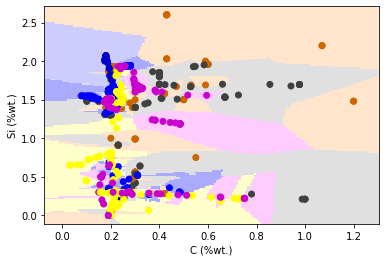

In [18]:
from matplotlib.colors import ListedColormap
cmap_light = ListedColormap(['#E0E0E0','#CCCCFF','#AAAAFF','#FFFFCC','#FFE5CC','#FFCCFF'])
cmap_bold = ListedColormap(['#404040','#0000CC','#0000FF','yellow','#CC6600','#CC00CC'])
X_c_si = dataset.iloc[:,:2]
X_sm,y_sm = oversample.fit_resample(X_c_si,y)
#X_c_si_sc = sc.fit_transform(X_c_si)
#X_c_si_pca = pca.fit_transform(X_c_si_sc)
knn = KNeighborsClassifier(n_neighbors=3,algorithm='ball_tree',leaf_size=20)
#knn.fit(X_c_si,y)
knn.fit(X_sm,y_sm)
#x_min, x_max = X_c_si_sc[:,0].min() - 0.1, X_c_si_sc[:,0].max()+0.1
#y_min, y_max = X_c_si_sc[:,1].min() - 0.1, X_c_si_sc[:,1].max()+0.1

# x_min, x_max = X_c_si.iloc[:,0].min() - 0.1, X_c_si.iloc[:,0].max()+0.1
# y_min, y_max = X_c_si.iloc[:,1].min() - 0.1, X_c_si.iloc[:,1].max()+0.1

x_min, x_max = X_sm.iloc[:,0].min() - 0.1, X_sm.iloc[:,0].max()+0.1
y_min, y_max = X_sm.iloc[:,1].min() - 0.1, X_sm.iloc[:,1].max()+0.1

xx, yy = np.meshgrid(np.linspace(x_min,x_max,150),
                     np.linspace(y_min,y_max,150))
Z = knn.predict(np.c_[xx.ravel(),yy.ravel()])

Z = Z.reshape(xx.shape)
plt.figure()
plt.pcolormesh(xx,yy,Z,cmap=cmap_light)
plt.scatter(X_sm.iloc[:,0],X_sm.iloc[:,1],c=y_sm,cmap=cmap_bold)
#plt.scatter(X_c_si_sc[:,0],X_c_si_sc[:,1],c=y,cmap=cmap_bold)
plt.xlabel('C (%wt.)')
plt.ylabel('Si (%wt.)')
plt.savefig('Plot_knn_C_k3.png',dpi = 400)

C:\Users\META2020\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


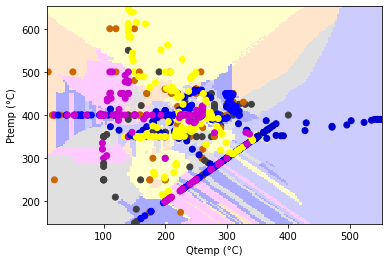

In [15]:
from matplotlib.colors import ListedColormap
cmap_light = ListedColormap(['#E0E0E0','#CCCCFF','#AAAAFF','#FFFFCC','#FFE5CC','#FFCCFF'])
cmap_bold = ListedColormap(['#404040','#0000CC','#0000FF','yellow','#CC6600','#CC00CC'])
X_QP = dataset.iloc[:,7:9]
X_sm,y_sm = oversample.fit_resample(X_QP,y)
#X_c_si_sc = sc.fit_transform(X_c_si)
#X_c_si_pca = pca.fit_transform(X_c_si_sc)
knn = KNeighborsClassifier(n_neighbors=5,algorithm='ball_tree',leaf_size=20)
#knn.fit(X_c_si,y)
knn.fit(X_sm,y_sm)
#x_min, x_max = X_c_si_sc[:,0].min() - 0.1, X_c_si_sc[:,0].max()+0.1
#y_min, y_max = X_c_si_sc[:,1].min() - 0.1, X_c_si_sc[:,1].max()+0.1

# x_min, x_max = X_c_si.iloc[:,0].min() - 0.1, X_c_si.iloc[:,0].max()+0.1
# y_min, y_max = X_c_si.iloc[:,1].min() - 0.1, X_c_si.iloc[:,1].max()+0.1

x_min, x_max = X_sm.iloc[:,0].min() - 0.1, X_sm.iloc[:,0].max()+0.1
y_min, y_max = X_sm.iloc[:,1].min() - 0.1, X_sm.iloc[:,1].max()+0.1

xx, yy = np.meshgrid(np.linspace(x_min,x_max,150),
                     np.linspace(y_min,y_max,150))
Z = knn.predict(np.c_[xx.ravel(),yy.ravel()])

Z = Z.reshape(xx.shape)
plt.figure()
plt.pcolormesh(xx,yy,Z,cmap=cmap_light)
plt.scatter(X_sm.iloc[:,0],X_sm.iloc[:,1],c=y_sm,cmap=cmap_bold)
#plt.scatter(X_c_si_sc[:,0],X_c_si_sc[:,1],c=y,cmap=cmap_bold)
plt.xlabel(f'Qtemp (\N{DEGREE SIGN}C)')
plt.ylabel(f'Ptemp (\N{DEGREE SIGN}C)')
plt.savefig('Plot_knn_QP.png',dpi = 400)

## Random Forest Classifier 

In [21]:
clf = RandomForestClassifier(n_estimators=10, random_state=42)
param_dist = {
    "max_depth": [5, None],
    "max_features": randint(1, 11),
    "min_samples_split": randint(2, 11),
    "bootstrap": [True, False],
    "criterion": ["gini", "entropy"],
}

In [22]:
rsh = HalvingRandomSearchCV(
    estimator=clf, param_distributions=param_dist, factor=2, random_state=42
)
rsh.fit(X_train, y_train)
rsh.best_params_

{'bootstrap': True,
 'criterion': 'entropy',
 'max_depth': None,
 'max_features': 9,
 'min_samples_split': 3}

In [23]:
clf = RandomForestClassifier(n_estimators=10, bootstrap= True,
                             criterion = 'entropy',
                             max_depth= None,
                             max_features = 9,
                             min_samples_split = 3,
                             random_state=42)
clf.fit(X_train,y_train)

RandomForestClassifier(criterion='entropy', max_features=9, min_samples_split=3,
                       n_estimators=10, random_state=42)

In [24]:
y_pred_train = clf.predict(X_train)
y_pred = clf.predict(X_test)
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train)))
# print the scores on training and test set

print('Training set score: {:.4f}'.format(clf.score(X_train, y_train)))
print(f"Training set f1-score; f1_score ={f1_score(y_train, y_pred_train, average='macro')*100:0.1f}")
print('Test set score: {:.4f}'.format(clf.score(X_test, y_test)))
print(f"Test set f1-score; f1_score ={f1_score(y_test, y_pred, average='macro')*100:0.1f}")

Training-set accuracy score: 0.9543
Training set score: 0.9543
Training set f1-score; f1_score =95.4
Test set score: 0.7567
Test set f1-score; f1_score =75.1


In [26]:
expdata=pd.read_csv('expdata.csv')
X_newdata = sc.transform(expdata)
X_newdata = pca.transform(X_newdata)
y_pred_newdata = clf.predict(X_newdata)
y_pred_newdata[:]

array([4, 4, 4], dtype=int64)

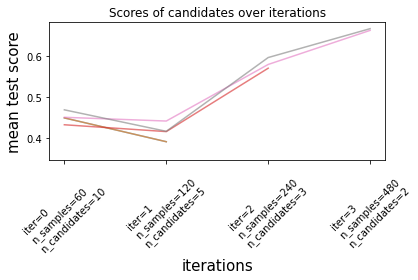

In [27]:
results = pd.DataFrame(rsh.cv_results_)
results["params_str"] = results.params.apply(str)
results.drop_duplicates(subset=("params_str", "iter"), inplace=True)
mean_scores = results.pivot(
    index="iter", columns="params_str", values="mean_test_score"
)
ax = mean_scores.plot(legend=False, alpha=0.6)

labels = [
    f"iter={i}\nn_samples={rsh.n_resources_[i]}\nn_candidates={rsh.n_candidates_[i]}"
    for i in range(rsh.n_iterations_)
]

ax.set_xticks(range(rsh.n_iterations_))
ax.set_xticklabels(labels, rotation=45, multialignment="left")
ax.set_title("Scores of candidates over iterations")
ax.set_ylabel("mean test score", fontsize=15)
ax.set_xlabel("iterations", fontsize=15)
plt.tight_layout()
plt.show()

At the first iteration, a small amount of resources is used. The resource here is the number of samples that the estimators are trained on. All candidates are evaluated.

At the second iteration, only the best half of the candidates is evaluated. The number of allocated resources is doubled: candidates are evaluated on twice as many samples.

This process is repeated until the last iteration, where only 2 candidates are left. The best candidate is the candidate that has the best score at the last iteration.

In [61]:
# # from sklearn.inspection import plot_partial_dependence
# from sklearn.inspection import PartialDependenceDisplay

# features = ["MedInc", "AveOccup", "HouseAge", "AveRooms"]
# est = RandomForestClassifier(n_estimators=10)
# est.fit(X_train, y_train)

# # plot_partial_dependence has been removed in version 1.2. From 1.2, use
# # PartialDependenceDisplay instead.
# # display = plot_partial_dependence(
# display = PartialDependenceDisplay.from_estimator(
#     est,
#     X,
#     #features,
#     kind="individual",
#     subsample=50,
#     n_jobs=3,
#     grid_resolution=20,
#     random_state=0,
# )
# display.figure_.suptitle(
#     "Partial dependence of house value on non-location features\n"
#     "for the California housing dataset, with BayesianRidge"
# )
# display.figure_.subplots_adjust(hspace=0.3)

## Support Vector Machine

In [21]:
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.svm import SVC
svc = SVC(gamma="auto",probability= False, kernel= 'rbf', degree = 5)
self_training_model = SelfTrainingClassifier(svc)
self_training_model.fit(X_train,y_train)

C:\Users\META2020\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\semi_supervised\_self_training.py:212: UserWarning: y contains no unlabeled samples
  warnings.warn("y contains no unlabeled samples", UserWarning)


SelfTrainingClassifier(base_estimator=SVC(degree=5, gamma='auto'))

In [22]:
y_pred_train = self_training_model.predict(X_train)
y_pred = self_training_model.predict(X_test)
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train)))
# print the scores on training and test set

print('Training set score: {:.4f}'.format(self_training_model.score(X_train, y_train)))
print(f"Training set f1-score; f1_score ={f1_score(y_train, y_pred_train, average='macro')*100:0.1f}")
print('Test set score: {:.4f}'.format(self_training_model.score(X_test, y_test)))
print(f"Test set f1-score; f1_score ={f1_score(y_test, y_pred, average='macro')*100:0.1f}")

Training-set accuracy score: 0.7064
Training set score: 0.7064
Training set f1-score; f1_score =69.5
Test set score: 0.6540
Test set f1-score; f1_score =63.7


## Extra_Plot

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


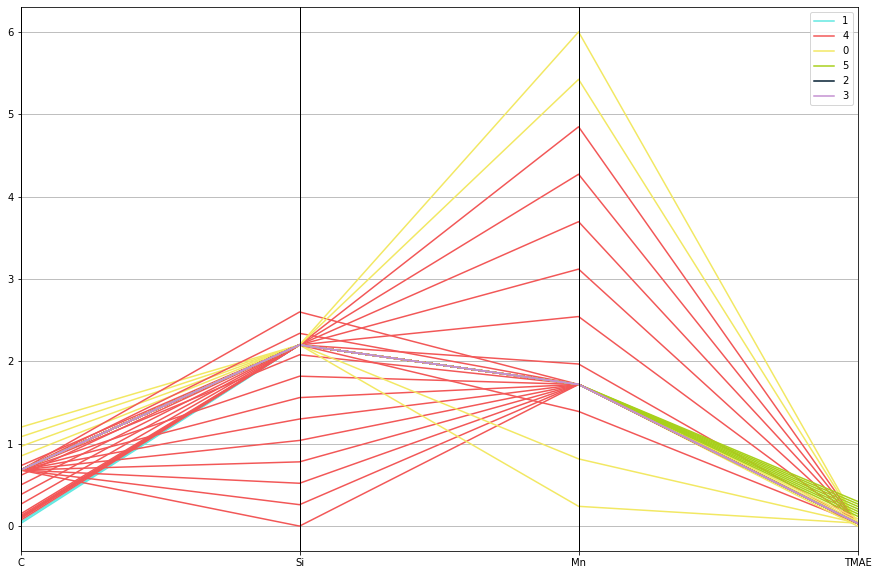

In [78]:
plt.figure(figsize=(15,10))
from pandas.plotting import parallel_coordinates
cols= ['C', 'Si', 'Mn', 'TMAE'] #, 'AC1', 'AC3', 'MS', 'Qtemp', 'Ptemp']
scaled_df = pd.DataFrame(newdata,columns=cols) #,columns=cols
y_pred_newdata_df = pd.DataFrame(y_pred_newdata,columns=['MicroStrucType'])
print(type(scaled_df))
print(type(y_pred_newdata_df))
final_df = pd.concat([scaled_df,y_pred_newdata_df],axis=1)
final_df[:5]
pc= parallel_coordinates(final_df,'MicroStrucType',color=('#61e8e1','#f25757','#f2e863','#A8D01B','#001b2e','#c490d1'))

In [56]:
dataset.columns

Index(['C', 'Si', 'Mn', 'TMAE', 'AC1', 'AC3', 'MS', 'Qtemp', 'Ptemp',
       'MicroStrucType'],
      dtype='object')

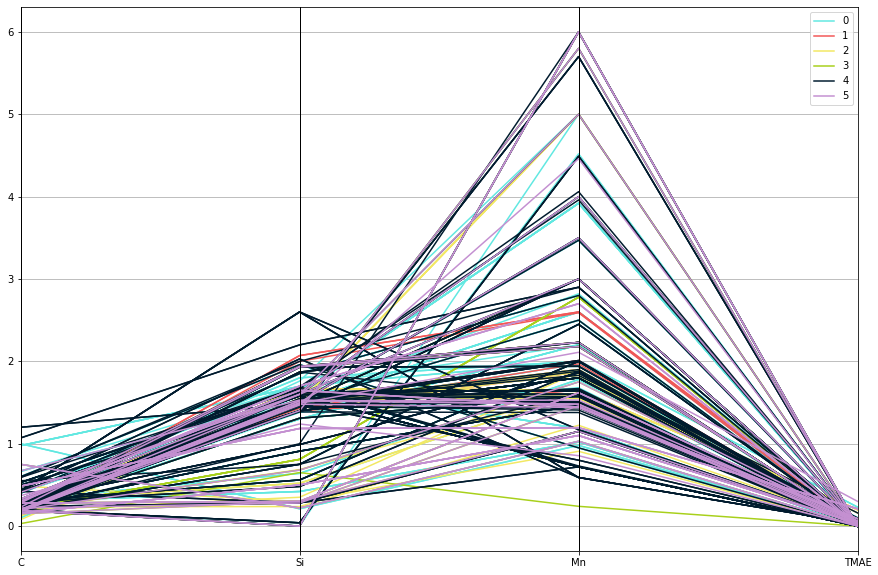

In [80]:
plt.figure(figsize=(15,10))
from pandas.plotting import parallel_coordinates
cols= ['C', 'Si', 'Mn', 'TMAE'] #, 'AC1', 'AC3', 'MS', 'Qtemp', 'Ptemp']
scaled_df = pd.DataFrame(dataset,columns=cols) #,columns=cols
#y_pred_newdata_df = pd.DataFrame(y_pred_newdata,columns=['MicroStrucType'])
#print(type(scaled_df))
#print(type(y_pred_newdata_df))
final_df = pd.concat([scaled_df,dataset['MicroStrucType']],axis=1)
#final_df[:5]
pc= parallel_coordinates(final_df,'MicroStrucType',color=('#61e8e1','#f25757','#f2e863','#A8D01B','#001b2e','#c490d1'))